In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-learn', 'matplotlib'], check=True)
print("Done.")

Mounted at /content/drive
Done.


In [ ]:
import math, string, glob, os, json, time, itertools
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

VOCAB      = list(string.ascii_lowercase + string.digits) + ['<PAD>', '<UNK>']
C2I        = {c: i for i, c in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)   # 38
PAD_IDX    = C2I['<PAD>'] # 36
MAX_LEN    = 512
KEY        = "CIPHER"
KEY_LEN    = len(KEY)     # 6

BASE_DIR  = "/content/drive/MyDrive/keyless_cipher/data/cipher_datasets_english_1000"
SAVE_DIR  = "/content/drive/MyDrive/keyless_cipher/p2_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")

Device: cuda
Save dir: /content/drive/MyDrive/keyless_cipher/p2_outputs


In [ ]:
def encode(text):
    ids = [C2I.get(c, C2I['<UNK>']) for c in text[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def get_padding_mask(x):
    return x == PAD_IDX

class CipherDataset(Dataset):
    def __init__(self, cipher_dir, split):
        path = os.path.join(cipher_dir, f"{split}.json")
        with open(path, encoding="utf-8") as f:
            records = json.load(f)
        self.pairs = []
        for r in records:
            enc   = ''.join(c for c in r['ciphertext'].lower() if c in C2I)
            plain = ''.join(c for c in r['plaintext'].lower()  if c in C2I)
            if len(enc) < 50 or len(plain) < 50:
                continue
            self.pairs.append((encode(enc), encode(plain)))
        print(f"  {split:5s}: {len(self.pairs)} pairs")

    def __len__(self): return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]

def build_loaders(cipher_name, batch_size=32):
    cipher_dir = os.path.join(BASE_DIR, cipher_name)
    print(f"Loading: {cipher_name}")
    train_ds = CipherDataset(cipher_dir, "train")
    val_ds   = CipherDataset(cipher_dir, "val")
    test_ds  = CipherDataset(cipher_dir, "test")
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2),
    )

train_loader, val_loader, test_loader = build_loaders("vigenere")
print("\nData ready.")

Loading: vigenere
  train: 700 pairs
  val  : 150 pairs
  test : 150 pairs

Data ready.


In [ ]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class LearnedPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.pe      = nn.Embedding(max_len, d_model)
        nn.init.normal_(self.pe.weight, std=0.02)

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        return self.dropout(x + self.pe(pos))


class TransformerLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_ff, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, dim_ff), nn.ReLU(), nn.Linear(dim_ff, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        out, _ = self.attn(x, x, x, key_padding_mask=key_padding_mask, need_weights=False)
        x = self.norm1(x + self.drop(out))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class FlexTransformer(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=256, nhead=8,
                 num_layers=4, dim_ff=1024, dropout=0.1, pe_type="sinusoidal"):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe     = (SinusoidalPE(d_model, dropout=dropout)
                       if pe_type == "sinusoidal"
                       else LearnedPE(d_model, dropout=dropout))
        self.layers = nn.ModuleList([
            TransformerLayer(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])
        self.proj  = nn.Linear(d_model, vocab_size)
        self.scale = math.sqrt(d_model)

    def forward(self, x, key_padding_mask=None):
        x = self.pe(self.embed(x) * self.scale)
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_padding_mask)
        return self.proj(x)



class LSTMDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 hidden=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm  = nn.LSTM(embed_dim, hidden, num_layers=num_layers,
                             batch_first=True, bidirectional=True,
                             dropout=dropout if num_layers > 1 else 0)
        self.proj  = nn.Linear(hidden * 2, vocab_size)

    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.proj(out)

print("Models defined.")

Models defined.


In [ ]:
CRITERION = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, loader, optimizer, is_tf):
    model.train()
    total = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        out  = model(src, key_padding_mask=get_padding_mask(src)) if is_tf else model(src)
        loss = CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, is_tf):
    model.eval()
    correct = total = loss_sum = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            out  = model(src, key_padding_mask=get_padding_mask(src)) if is_tf else model(src)
            loss_sum += CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1)).item()
            pred = out.argmax(-1)
            mask = tgt != PAD_IDX
            correct += (pred[mask] == tgt[mask]).sum().item()
            total   += mask.sum().item()
    return loss_sum / len(loader), correct / total

print("Training helpers ready.")

Training helpers ready.


In [ ]:
LSTM_PATH = os.path.join(SAVE_DIR, "lstm_reference.pt")

lstm_ref = LSTMDecryptor().to(DEVICE)
opt      = torch.optim.Adam(lstm_ref.parameters(), lr=1e-3)
sched    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)
best_val = float('inf')

print("Training LSTM reference (50 epochs)...")
print(f"Params: {sum(p.numel() for p in lstm_ref.parameters()):,}")

for epoch in range(1, 51):
    train_epoch(lstm_ref, train_loader, opt, is_tf=False)
    val_loss, val_acc = evaluate(lstm_ref, val_loader, is_tf=False)
    sched.step()
    if val_loss < best_val:
        best_val = val_loss
        torch.save(lstm_ref.state_dict(), LSTM_PATH)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:2d}  val_acc={val_acc*100:.2f}%")

lstm_ref.load_state_dict(torch.load(LSTM_PATH, map_location=DEVICE))
_, lstm_char_acc_frac = evaluate(lstm_ref, test_loader, is_tf=False)
LSTM_CHAR_ACC = round(lstm_char_acc_frac * 100, 2)
print(f"\nLSTM test char acc: {LSTM_CHAR_ACC}%  (saved to {LSTM_PATH})")

Training LSTM reference (50 epochs)...
Params: 2,391,846
  Epoch 10  val_acc=99.84%
  Epoch 20  val_acc=99.87%
  Epoch 30  val_acc=99.86%
  Epoch 40  val_acc=99.86%
  Epoch 50  val_acc=99.86%

LSTM test char acc: 99.9%  (saved to /content/drive/MyDrive/keyless_cipher/p2_outputs/lstm_reference.pt)


In [ ]:
LAYERS   = [2, 4, 6, 8]
D_MODELS = [128, 256, 512]
PE_TYPES = ["sinusoidal", "learned"]
NHEAD    = {128: 4, 256: 8, 512: 8}
EPOCHS_GRID = 25

configs = [
    {"num_layers": l, "d_model": d, "pe_type": pe,
     "nhead": NHEAD[d], "dim_ff": d * 4}
    for l, d, pe in itertools.product(LAYERS, D_MODELS, PE_TYPES)
]
print(f"Total configs: {len(configs)}")

print(f"\n{'#':<4} {'layers':<8} {'d_model':<9} {'PE':<13} {'params (approx)'}")
print("-" * 50)
for i, c in enumerate(configs):
    dummy = FlexTransformer(**c)
    np_   = sum(p.numel() for p in dummy.parameters())
    print(f"{i+1:<4} {c['num_layers']:<8} {c['d_model']:<9} {c['pe_type']:<13} {np_:,}")
    del dummy

Total configs: 24

#    layers   d_model   PE            params (approx)
--------------------------------------------------
1    2        128       sinusoidal    406,310
2    2        128       learned       471,846
3    2        256       sinusoidal    1,599,014
4    2        256       learned       1,730,086
5    2        512       sinusoidal    6,343,718
6    2        512       learned       6,605,862
7    4        128       sinusoidal    802,854
8    4        128       learned       868,390
9    4        256       sinusoidal    3,178,534
10   4        256       learned       3,309,606
11   4        512       sinusoidal    12,648,486
12   4        512       learned       12,910,630
13   6        128       sinusoidal    1,199,398
14   6        128       learned       1,264,934
15   6        256       sinusoidal    4,758,054
16   6        256       learned       4,889,126
17   6        512       sinusoidal    18,953,254
18   6        512       learned       19,215,398
19   8        12

In [ ]:
RESULTS_PATH = os.path.join(SAVE_DIR, "p2_grid_results.json")

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        results = json.load(f)
    print(f"Resuming — {len(results)}/{len(configs)} configs already done.")
else:
    results = []

completed_keys = {(r["num_layers"], r["d_model"], r["pe_type"]) for r in results}

for i, cfg in enumerate(configs):
    key = (cfg["num_layers"], cfg["d_model"], cfg["pe_type"])
    if key in completed_keys:
        print(f"[{i+1:2d}/{len(configs)}] Skipping: layers={cfg['num_layers']} d_model={cfg['d_model']} pe={cfg['pe_type']}")
        continue

    print(f"\n[{i+1:2d}/{len(configs)}] layers={cfg['num_layers']}  d_model={cfg['d_model']}  pe={cfg['pe_type']}")
    model    = FlexTransformer(**cfg).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Params: {n_params:,}")

    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_GRID)
    best_val_loss = float('inf')
    best_val_acc  = 0.0
    t0 = time.time()

    for epoch in range(1, EPOCHS_GRID + 1):
        train_epoch(model, train_loader, opt, is_tf=True)
        val_loss, val_acc = evaluate(model, val_loader, is_tf=True)
        sched.step()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc  = val_acc
        if epoch % 5 == 0:
            print(f"  Epoch {epoch:2d}  val_acc={val_acc*100:.2f}%")

    elapsed = time.time() - t0
    record  = {
        "num_layers"    : cfg["num_layers"],
        "d_model"       : cfg["d_model"],
        "nhead"         : cfg["nhead"],
        "dim_ff"        : cfg["dim_ff"],
        "pe_type"       : cfg["pe_type"],
        "n_params"      : n_params,
        "best_val_loss" : round(best_val_loss, 6),
        "best_char_acc" : round(best_val_acc * 100, 2),
        "elapsed_s"     : round(elapsed, 1),
    }
    results.append(record)
    completed_keys.add(key)


    with open(RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)

    print(f"  DONE  char_acc={record['best_char_acc']:.2f}%  time={elapsed:.0f}s  "
          f"[saved {len(results)}/{len(configs)}]")

print(f"\nGrid search complete.")


[ 1/24] layers=2  d_model=128  pe=sinusoidal
  Params: 406,310
  Epoch  5  val_acc=38.84%
  Epoch 10  val_acc=38.79%
  Epoch 15  val_acc=38.61%
  Epoch 20  val_acc=39.29%
  Epoch 25  val_acc=39.35%
  DONE  char_acc=39.36%  time=35s  [saved 1/24]

[ 2/24] layers=2  d_model=128  pe=learned
  Params: 471,846
  Epoch  5  val_acc=39.10%
  Epoch 10  val_acc=38.91%
  Epoch 15  val_acc=39.14%
  Epoch 20  val_acc=39.30%
  Epoch 25  val_acc=39.35%
  DONE  char_acc=39.35%  time=35s  [saved 2/24]

[ 3/24] layers=2  d_model=256  pe=sinusoidal
  Params: 1,599,014
  Epoch  5  val_acc=37.76%
  Epoch 10  val_acc=38.55%
  Epoch 15  val_acc=38.89%
  Epoch 20  val_acc=39.40%
  Epoch 25  val_acc=39.41%
  DONE  char_acc=39.41%  time=76s  [saved 3/24]

[ 4/24] layers=2  d_model=256  pe=learned
  Params: 1,730,086
  Epoch  5  val_acc=38.49%
  Epoch 10  val_acc=39.09%
  Epoch 15  val_acc=39.00%
  Epoch 20  val_acc=39.13%
  Epoch 25  val_acc=39.44%
  DONE  char_acc=39.44%  time=76s  [saved 4/24]

[ 5/24] layer

In [ ]:
with open(RESULTS_PATH) as f:
    results = json.load(f)

sorted_results = sorted(results, key=lambda x: x['best_char_acc'], reverse=True)
best_tf        = sorted_results[0]['best_char_acc']
worst_tf       = sorted_results[-1]['best_char_acc']

print("=" * 75)
print("  PRIORITY 2 — TRANSFORMER HYPERPARAMETER SEARCH ON VIGENÈRE")
print("=" * 75)
print(f"  LSTM reference:   {LSTM_CHAR_ACC}%")
print(f"  Chance baseline:  ~2.6%")
print("=" * 75)

print(f"\n{'Rank':<5} {'Layers':<8} {'d_model':<9} {'PE':<13} {'Params':>12} {'Char Acc':>10}")
print("-" * 62)
for rank, r in enumerate(sorted_results, 1):
    flag = "  ← best TF" if rank == 1 else ("  ← worst TF" if rank == len(sorted_results) else "")
    print(f"{rank:<5} {r['num_layers']:<8} {r['d_model']:<9} {r['pe_type']:<13} "
          f"{r['n_params']:>12,} {r['best_char_acc']:>9.2f}%{flag}")

print(f"\nBest Transformer:   {best_tf:.2f}%")
print(f"Worst Transformer:  {worst_tf:.2f}%")
print(f"LSTM reference:     {LSTM_CHAR_ACC}%")
print(f"Gap (best TF vs LSTM): {LSTM_CHAR_ACC - best_tf:.2f} percentage points")

  PRIORITY 2 — TRANSFORMER HYPERPARAMETER SEARCH ON VIGENÈRE
  LSTM reference:   99.9%
  Chance baseline:  ~2.6%

Rank  Layers   d_model   PE                  Params   Char Acc
--------------------------------------------------------------
1     4        128       learned            868,390     39.51%  ← best TF
2     4        256       sinusoidal       3,178,534     39.48%
3     2        256       learned          1,730,086     39.44%
4     6        256       sinusoidal       4,758,054     39.44%
5     2        256       sinusoidal       1,599,014     39.41%
6     6        256       learned          4,889,126     39.41%
7     6        512       learned         19,215,398     39.41%
8     8        128       sinusoidal       1,595,942     39.41%
9     8        256       sinusoidal       6,337,574     39.41%
10    8        256       learned          6,468,646     39.41%
11    6        128       sinusoidal       1,199,398     39.40%
12    2        512       learned          6,605,862     

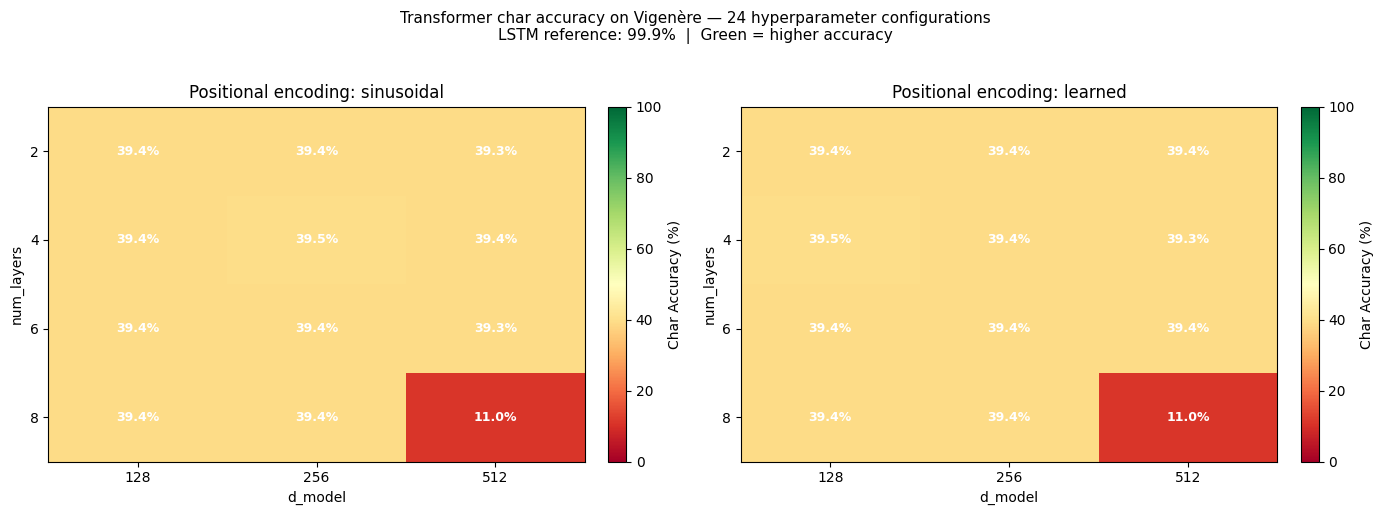

Saved: fig_p2_heatmap.pdf


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Transformer char accuracy on Vigenère — 24 hyperparameter configurations\n"
    f"LSTM reference: {LSTM_CHAR_ACC}%  |  Green = higher accuracy",
    fontsize=11, y=1.02
)

for ax, pe in zip(axes, ["sinusoidal", "learned"]):
    matrix = np.zeros((len(LAYERS), len(D_MODELS)))
    for r in results:
        if r["pe_type"] != pe:
            continue
        row = LAYERS.index(r["num_layers"])
        col = D_MODELS.index(r["d_model"])
        matrix[row, col] = r["best_char_acc"]

    im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=100)
    ax.set_xticks(range(len(D_MODELS))); ax.set_xticklabels(D_MODELS)
    ax.set_yticks(range(len(LAYERS)));   ax.set_yticklabels(LAYERS)
    ax.set_xlabel("d_model")
    ax.set_ylabel("num_layers")
    ax.set_title(f"Positional encoding: {pe}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Char Accuracy (%)")

    for i in range(len(LAYERS)):
        for j in range(len(D_MODELS)):
            val   = matrix[i, j]
            color = "white" if val < 50 else "black"
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_p2_heatmap.pdf"))
plt.show()
print("Saved: fig_p2_heatmap.pdf")

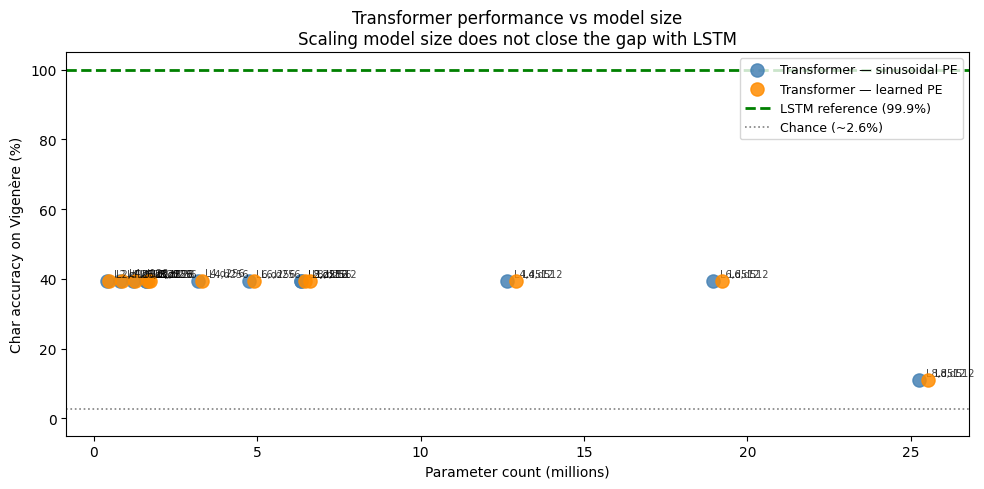

Saved: fig_p2_scaling.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_pe = {"sinusoidal": "steelblue", "learned": "darkorange"}

for pe_type, c in colors_pe.items():
    grp = [r for r in results if r["pe_type"] == pe_type]
    ax.scatter([r["n_params"]/1e6 for r in grp],
               [r["best_char_acc"]   for r in grp],
               c=c, label=f"Transformer — {pe_type} PE",
               s=90, alpha=0.85, zorder=3)
    for r in grp:
        ax.annotate(f"L{r['num_layers']},d{r['d_model']}",
                    (r["n_params"]/1e6, r["best_char_acc"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.75)

ax.axhline(LSTM_CHAR_ACC, color="green",  linestyle="--", linewidth=2,
           label=f"LSTM reference ({LSTM_CHAR_ACC}%)")
ax.axhline(2.6, color="gray", linestyle=":", linewidth=1.2,
           label="Chance (~2.6%)")

ax.set_xlabel("Parameter count (millions)")
ax.set_ylabel("Char accuracy on Vigenère (%)")
ax.set_title("Transformer performance vs model size\n"
             "Scaling model size does not close the gap with LSTM")
ax.legend(fontsize=9)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_p2_scaling.pdf"))
plt.show()
print("Saved: fig_p2_scaling.pdf")